# Data Preprocessing Pipeline

Walks through each stage of `preprocess_patches.py` on a single image,
with full-resolution visualisation at every step.

**Pipeline:**
1. Load raw volume (C, Z, Y, X)
2. Maximum Intensity Projection along Z → (C, Y, X)
3. Per-channel percentile normalisation → [0, 1]
4. Tiling into patches + empty-patch filtering
5. Reconstruct tiled grid for visual sanity check

---
## 0 — Imports & helpers

In [ ]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from utils_data.preprocess_patches import (
    load_image,
    maximum_intensity_projection,
    best_z_slice,
    normalize_percentile,
    extract_patches,
    is_foreground_patch,
)

print('Imports OK')

Imports OK


In [55]:
# ── Visualisation helpers ────────────────────────────────────────────

def _black_to(rgb):
    """Colormap from black to the given RGB colour."""
    return LinearSegmentedColormap.from_list('', [(0, 0, 0), rgb])

CHANNEL_CMAPS = [
    _black_to((1, 0, 0)),   # ch0 — red
    _black_to((0, 1, 0)),   # ch1 — green
    _black_to((0, 0, 1)),   # ch2 — blue
]


def show_channels(image, title='', vmax_pct=99.5):
    """
    Show each channel of a (C, H, W) image side by side.

    Parameters
    ----------
    image : np.ndarray, shape (C, H, W)
    title : str, super-title
    vmax_pct : float, percentile used for display clipping
    """
    C = image.shape[0]
    fig, axes = plt.subplots(1, C, figsize=(6 * C, 6))
    if C == 1:
        axes = [axes]
    for c, ax in enumerate(axes):
        ch = image[c]
        vmax = np.percentile(ch, vmax_pct) if ch.max() > 0 else 1
        cmap = CHANNEL_CMAPS[c % len(CHANNEL_CMAPS)]
        ax.imshow(ch, cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(f'Ch {c}  min={ch.min():.3g}  max={ch.max():.3g}')
        ax.axis('off')
    if title:
        fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

---
## 1 — Load raw volume

In [56]:
# ── Point this at any raw microscopy file ──
IMAGE_PATH = '/run/media/anokhver/Data/Veronika/ctu/Microscopy/Microscopy/20251030/2_3_PSYHARMIN_2_Multichannel Z-Stack_20251030_67.vsi'
#IMAGE_PATH = '/run/media/anokhver/Data/Veronika/ctu/Microscopy/Microscopy/20251030/1_8_KONTROLA_1_Multichannel Z-Stack_20251030_118.vsi'

from pathlib import Path
volume = load_image(Path(IMAGE_PATH))   # (C, Z, Y, X)
C, Z, H, W = volume.shape
print(f'Raw volume: C={C}, Z={Z}, H={H}, W={W}, dtype={volume.dtype}')

2026-03-29 17:49:51 [INFO]   Loaded via aicsimageio: shape=(3, 31, 2304, 2304), dtype=uint16


Raw volume: C=3, Z=31, H=2304, W=2304, dtype=uint16


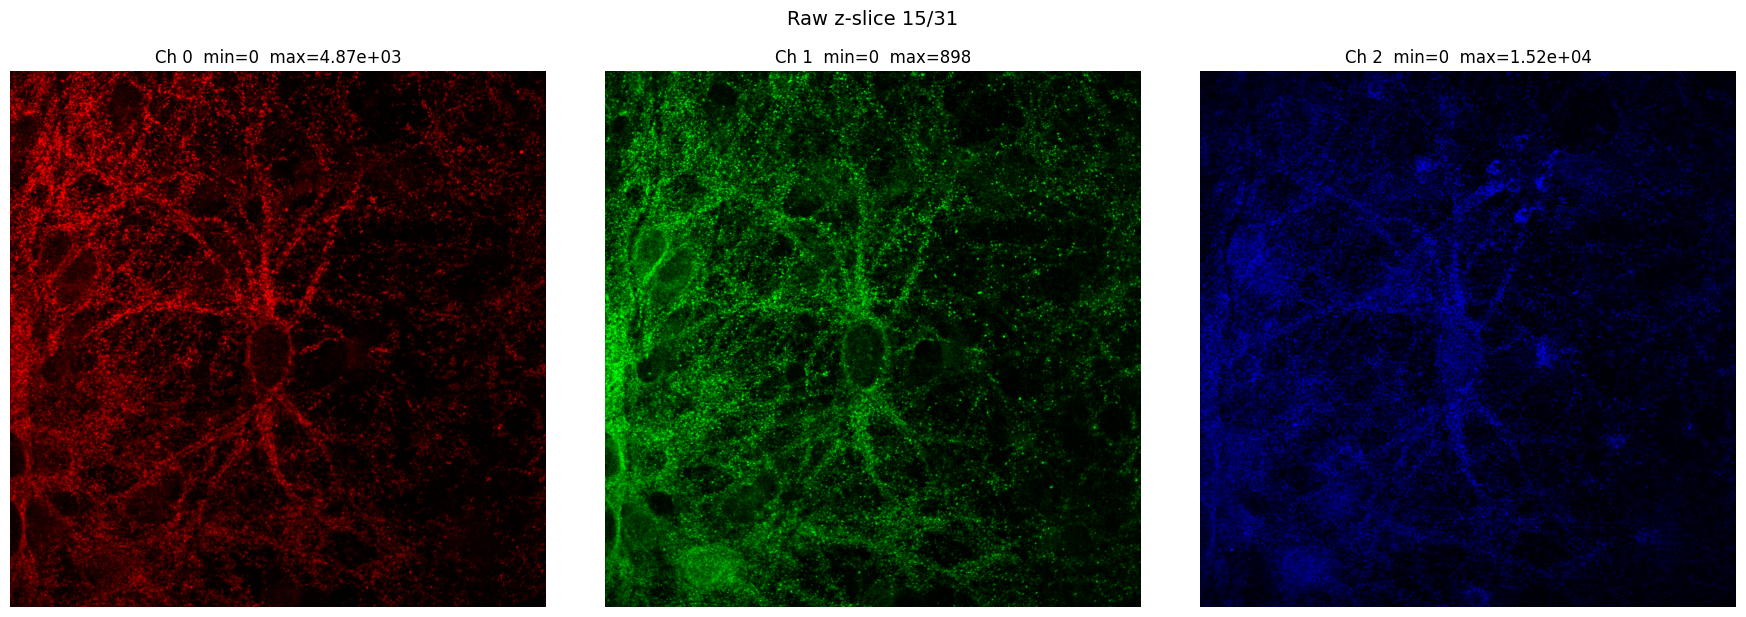

In [ ]:
best_z = best_z_slice(volume)
mid_z = Z // 2
print(f'Middle z-slice: {mid_z},  brightest z-slice: {best_z}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, z_idx, label in [(axes[0], mid_z, 'Middle'), (axes[1], best_z, 'Brightest')]:
    # composite: max across channels for a quick overview
    composite = volume[:, z_idx, :, :].astype(np.float32).max(axis=0)
    vmax = np.percentile(composite, 99.5) if composite.max() > 0 else 1
    ax.imshow(composite, cmap='gray', vmin=0, vmax=vmax)
    ax.set_title(f'{label} z={z_idx}')
    ax.axis('off')
plt.suptitle('Middle vs brightest z-slice (max across channels)', fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

# Show per-channel detail for the brightest slice
show_channels(volume[:, best_z, :, :].astype(np.float32),
              title=f'Brightest z-slice {best_z}/{Z}')

---
## 2 — Maximum Intensity Projection (MIP)

MIP shape: (3, 2304, 2304), dtype=float32


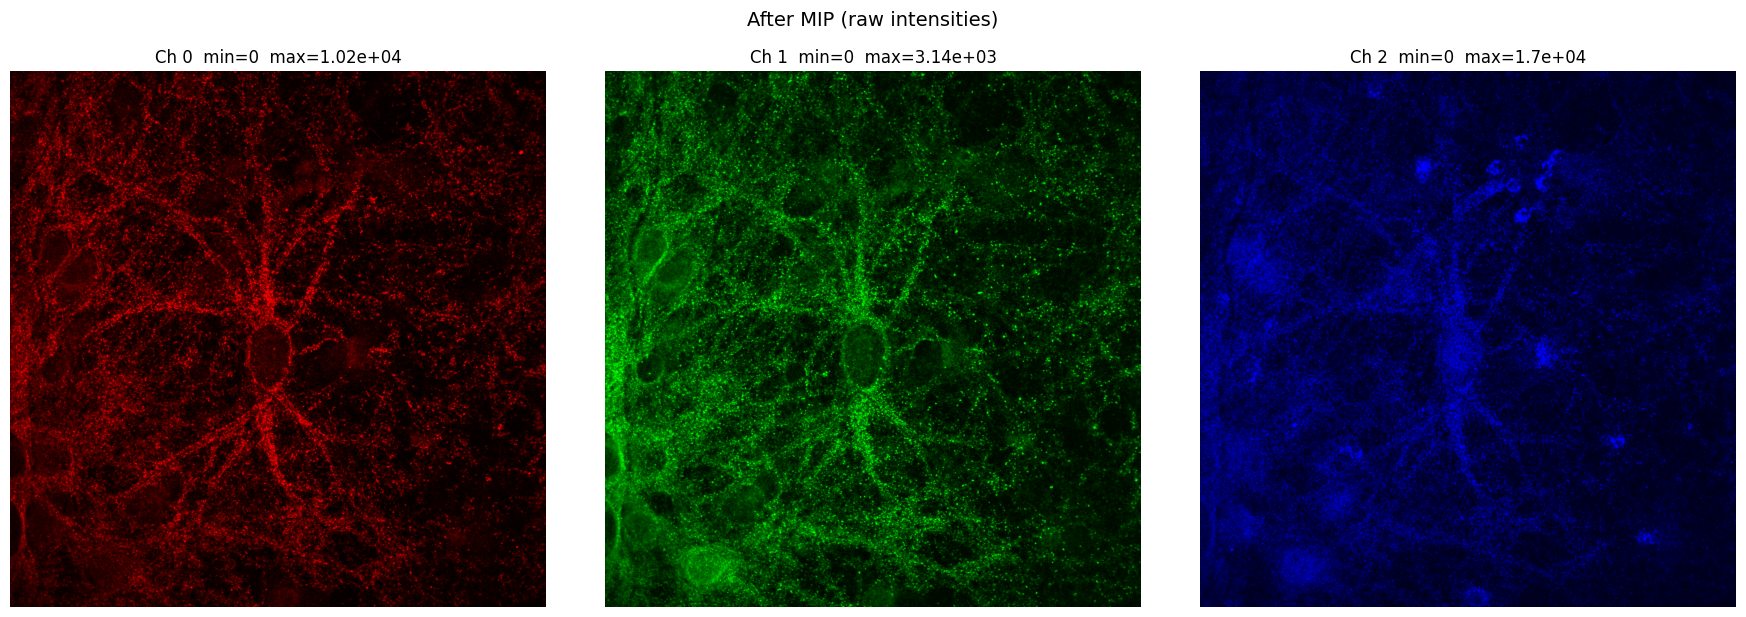

In [58]:
mip = maximum_intensity_projection(volume)   # (C, Y, X) float32
print(f'MIP shape: {mip.shape}, dtype={mip.dtype}')

# Free the large volume — we no longer need it
del volume

show_channels(mip, title='After MIP (raw intensities)')

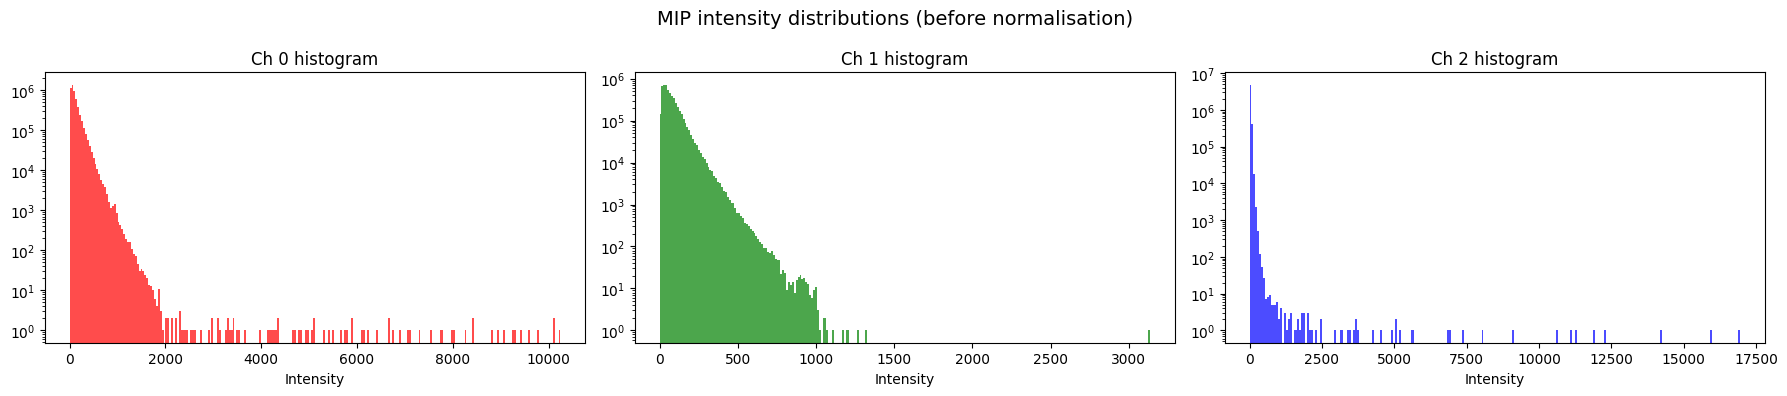

In [59]:
# Per-channel intensity histograms before normalisation
fig, axes = plt.subplots(1, mip.shape[0], figsize=(6 * mip.shape[0], 4))
if mip.shape[0] == 1:
    axes = [axes]
for c, ax in enumerate(axes):
    vals = mip[c].ravel()
    ax.hist(vals, bins=256, color=['r', 'g', 'b'][c % 3], alpha=0.7)
    ax.set_title(f'Ch {c} histogram')
    ax.set_yscale('log')
    ax.set_xlabel('Intensity')
fig.suptitle('MIP intensity distributions (before normalisation)', fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

---
## 3 — Per-channel percentile normalisation

In [60]:
# ── Tweak these to experiment ──
PLOW  = 1.0
PHIGH = 99.8

mip_norm = normalize_percentile(mip, plow=PLOW, phigh=PHIGH)
print(f'Normalised range per channel:')
for c in range(mip_norm.shape[0]):
    print(f'  Ch {c}: [{mip_norm[c].min():.4f}, {mip_norm[c].max():.4f}]')

Normalised range per channel:
  Ch 0: [0.0000, 1.0000]
  Ch 1: [0.0000, 1.0000]
  Ch 2: [0.0000, 1.0000]


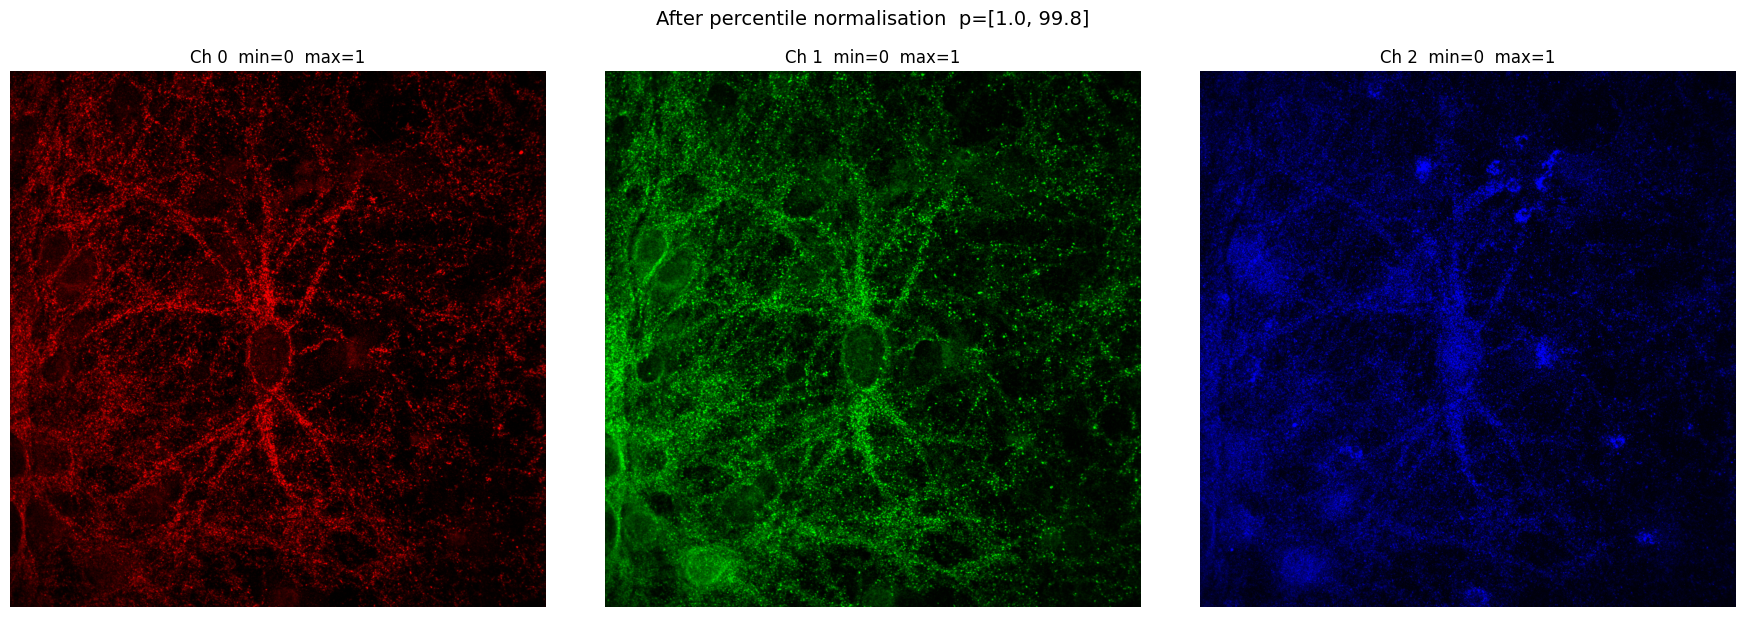

In [61]:
show_channels(mip_norm, title=f'After percentile normalisation  p=[{PLOW}, {PHIGH}]')

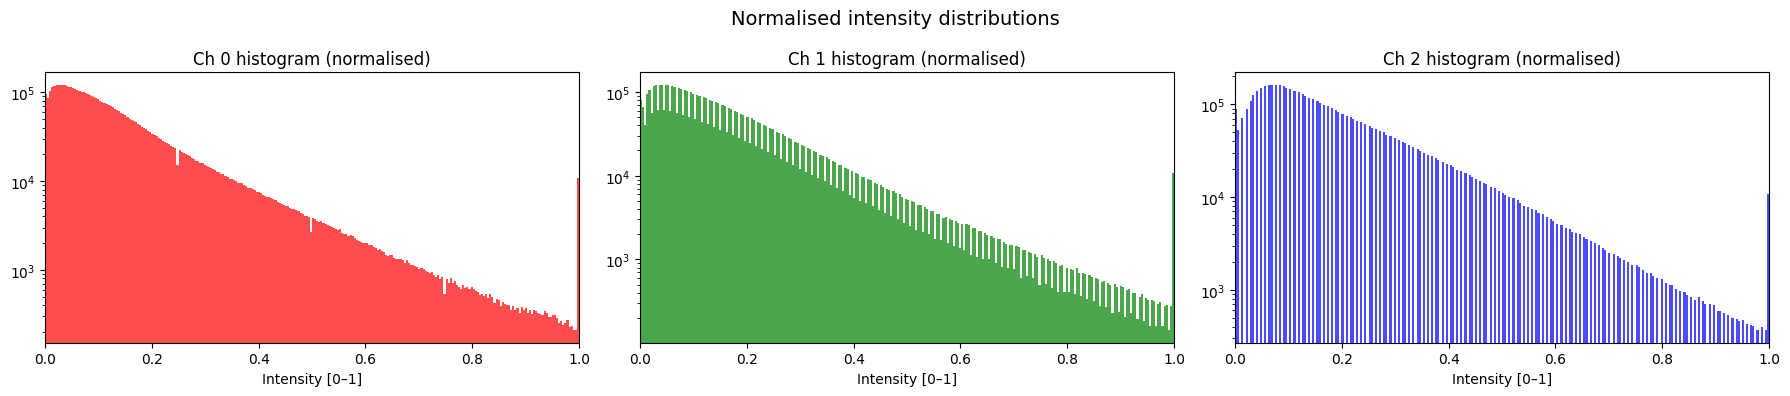

In [62]:
# Per-channel histograms after normalisation
fig, axes = plt.subplots(1, mip_norm.shape[0], figsize=(6 * mip_norm.shape[0], 4))
if mip_norm.shape[0] == 1:
    axes = [axes]
for c, ax in enumerate(axes):
    vals = mip_norm[c].ravel()
    ax.hist(vals, bins=256, color=['r', 'g', 'b'][c % 3], alpha=0.7)
    ax.set_title(f'Ch {c} histogram (normalised)')
    ax.set_yscale('log')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Intensity [0–1]')
fig.suptitle('Normalised intensity distributions', fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

---
## 4 — Tiling into patches + foreground filtering

In [ ]:
# ── Tweak these to experiment ──
PATCH_SIZE = 128
MIN_MEAN_INTENSITY = 0.04 # TODO - find a good value by looking at the histograms and patch samples

patches = extract_patches(mip_norm, patch_size=PATCH_SIZE)
n_total = patches.shape[0]

C_img, H_img, W_img = mip_norm.shape
n_rows = H_img // PATCH_SIZE
n_cols = W_img // PATCH_SIZE

print(f'Patches: {patches.shape}  ({n_rows} rows × {n_cols} cols = {n_total})')

Patches: (324, 3, 128, 128)  (18 rows × 18 cols = 324)


In [64]:
# Classify each patch as foreground / background
fg_mask = np.array([is_foreground_patch(patches[i], MIN_MEAN_INTENSITY)
                    for i in range(n_total)])
n_kept = fg_mask.sum()
print(f'Foreground patches: {n_kept}/{n_total}  '
      f'({100 * n_kept / n_total:.1f}% kept, '
      f'{n_total - n_kept} discarded)')

Foreground patches: 324/324  (100.0% kept, 0 discarded)


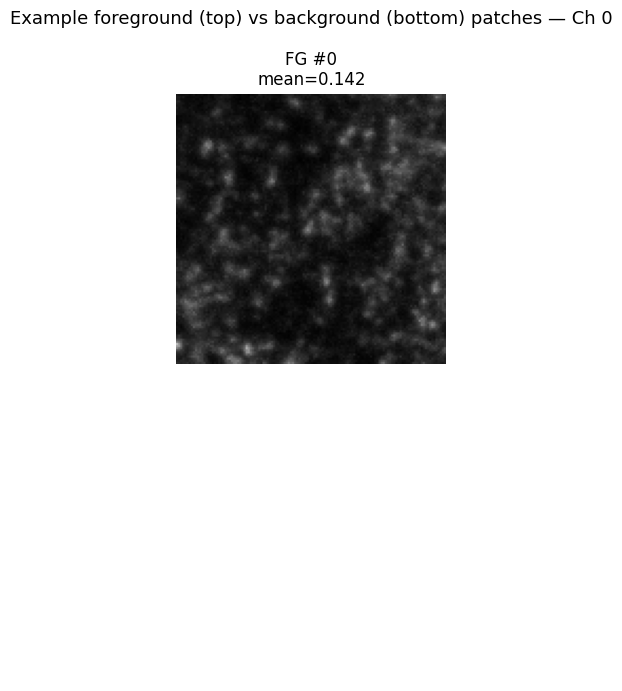

In [65]:
# Show a few example foreground and background patches
fg_idx = np.where(fg_mask)[0]
bg_idx = np.where(~fg_mask)[0]

n_show = min(5, len(fg_idx), max(1, len(bg_idx)))

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 7))
if n_show == 1:
    axes = axes.reshape(2, 1)

for i in range(n_show):
    # foreground
    p = patches[fg_idx[i]]
    # show channel 0 for simplicity
    axes[0, i].imshow(p[0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'FG #{fg_idx[i]}\nmean={p.mean():.3f}')
    axes[0, i].axis('off')

    # background (if any)
    if i < len(bg_idx):
        p = patches[bg_idx[i]]
        axes[1, i].imshow(p[0], cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title(f'BG #{bg_idx[i]}\nmean={p.mean():.3f}')
    axes[1, i].axis('off')

fig.suptitle('Example foreground (top) vs background (bottom) patches — Ch 0',
             fontsize=13)
plt.tight_layout()
plt.show()
plt.close(fig)

---
## 5 — Reassemble tile grid (visual sanity check)

Reconstruct the full image from patches, colouring discarded patches
differently so you can see exactly which regions are kept / dropped.

In [66]:
def reassemble_grid(patches, fg_mask, n_rows, n_cols, patch_size, channel=0):
    """
    Stitch patches back into a full-size image for a single channel.
    Discarded (background) patches are filled with NaN for distinct display.
    """
    H = n_rows * patch_size
    W = n_cols * patch_size
    canvas = np.full((H, W), np.nan, dtype=np.float32)

    for idx in range(len(patches)):
        r = idx // n_cols
        c = idx % n_cols
        y0 = r * patch_size
        x0 = c * patch_size
        if fg_mask[idx]:
            canvas[y0:y0 + patch_size, x0:x0 + patch_size] = patches[idx, channel]

    return canvas

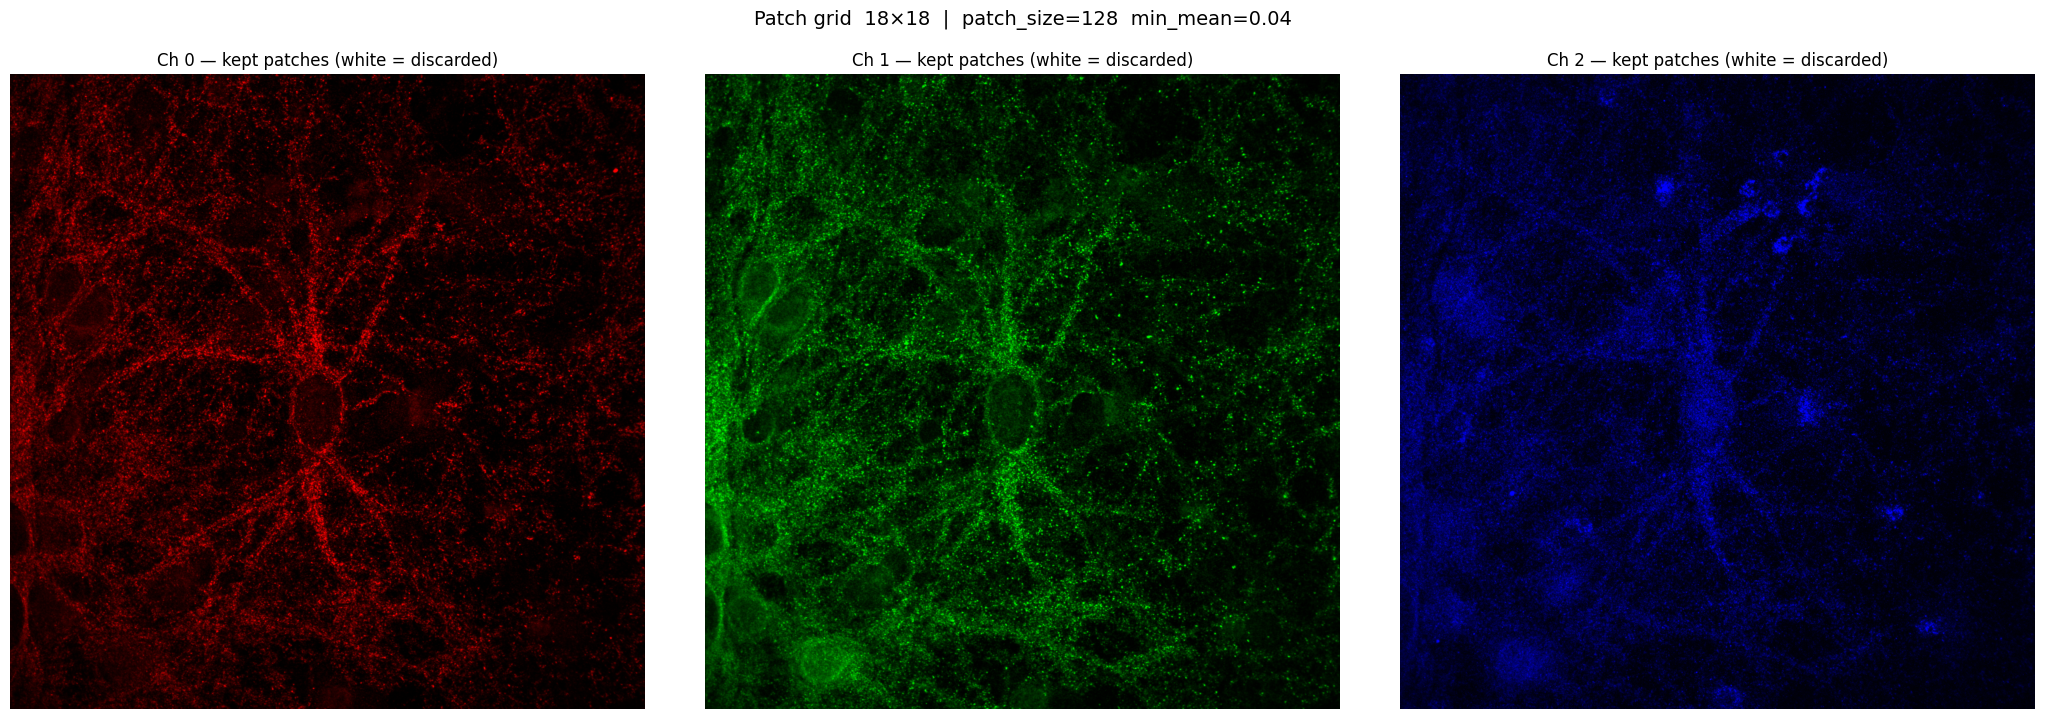

In [67]:
fig, axes = plt.subplots(1, C_img, figsize=(7 * C_img, 7))
if C_img == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    grid = reassemble_grid(patches, fg_mask, n_rows, n_cols, PATCH_SIZE, channel=c)
    cmap = CHANNEL_CMAPS[c % len(CHANNEL_CMAPS)].copy()
    cmap.set_bad(color='white')       # NaN → white (discarded patches)
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f'Ch {c} — kept patches (white = discarded)')
    ax.axis('off')

fig.suptitle(f'Patch grid  {n_rows}×{n_cols}  |  patch_size={PATCH_SIZE}  '
             f'min_mean={MIN_MEAN_INTENSITY}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

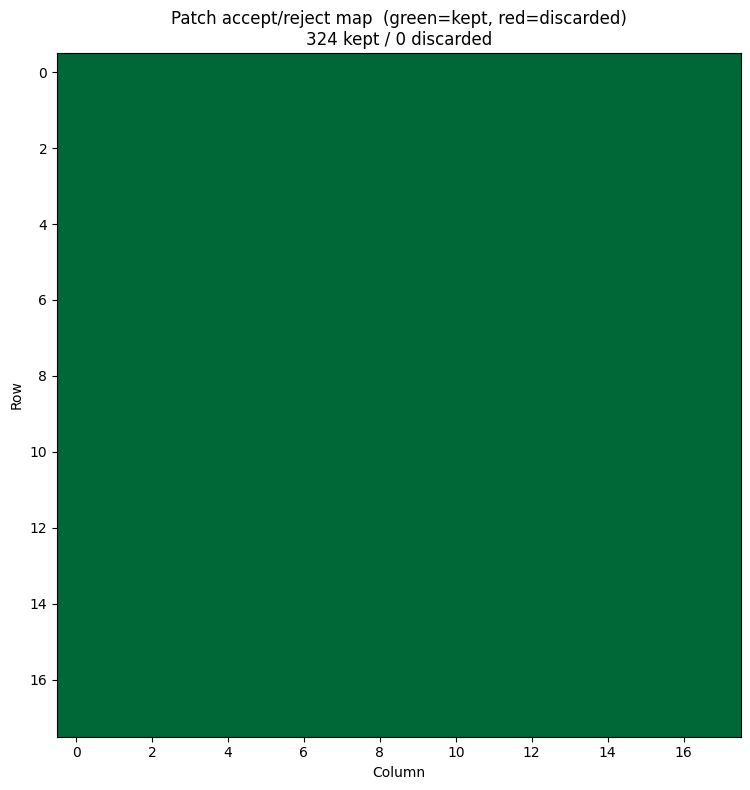

In [68]:
# Show the foreground/background grid map
fg_grid = fg_mask.reshape(n_rows, n_cols).astype(float)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(fg_grid, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_title(f'Patch accept/reject map  (green=kept, red=discarded)\n'
             f'{n_kept} kept / {n_total - n_kept} discarded')
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.tight_layout()
plt.show()
plt.close(fig)

---
## 6 — Side-by-side summary

Full normalised image vs. the patched & filtered version, per channel.

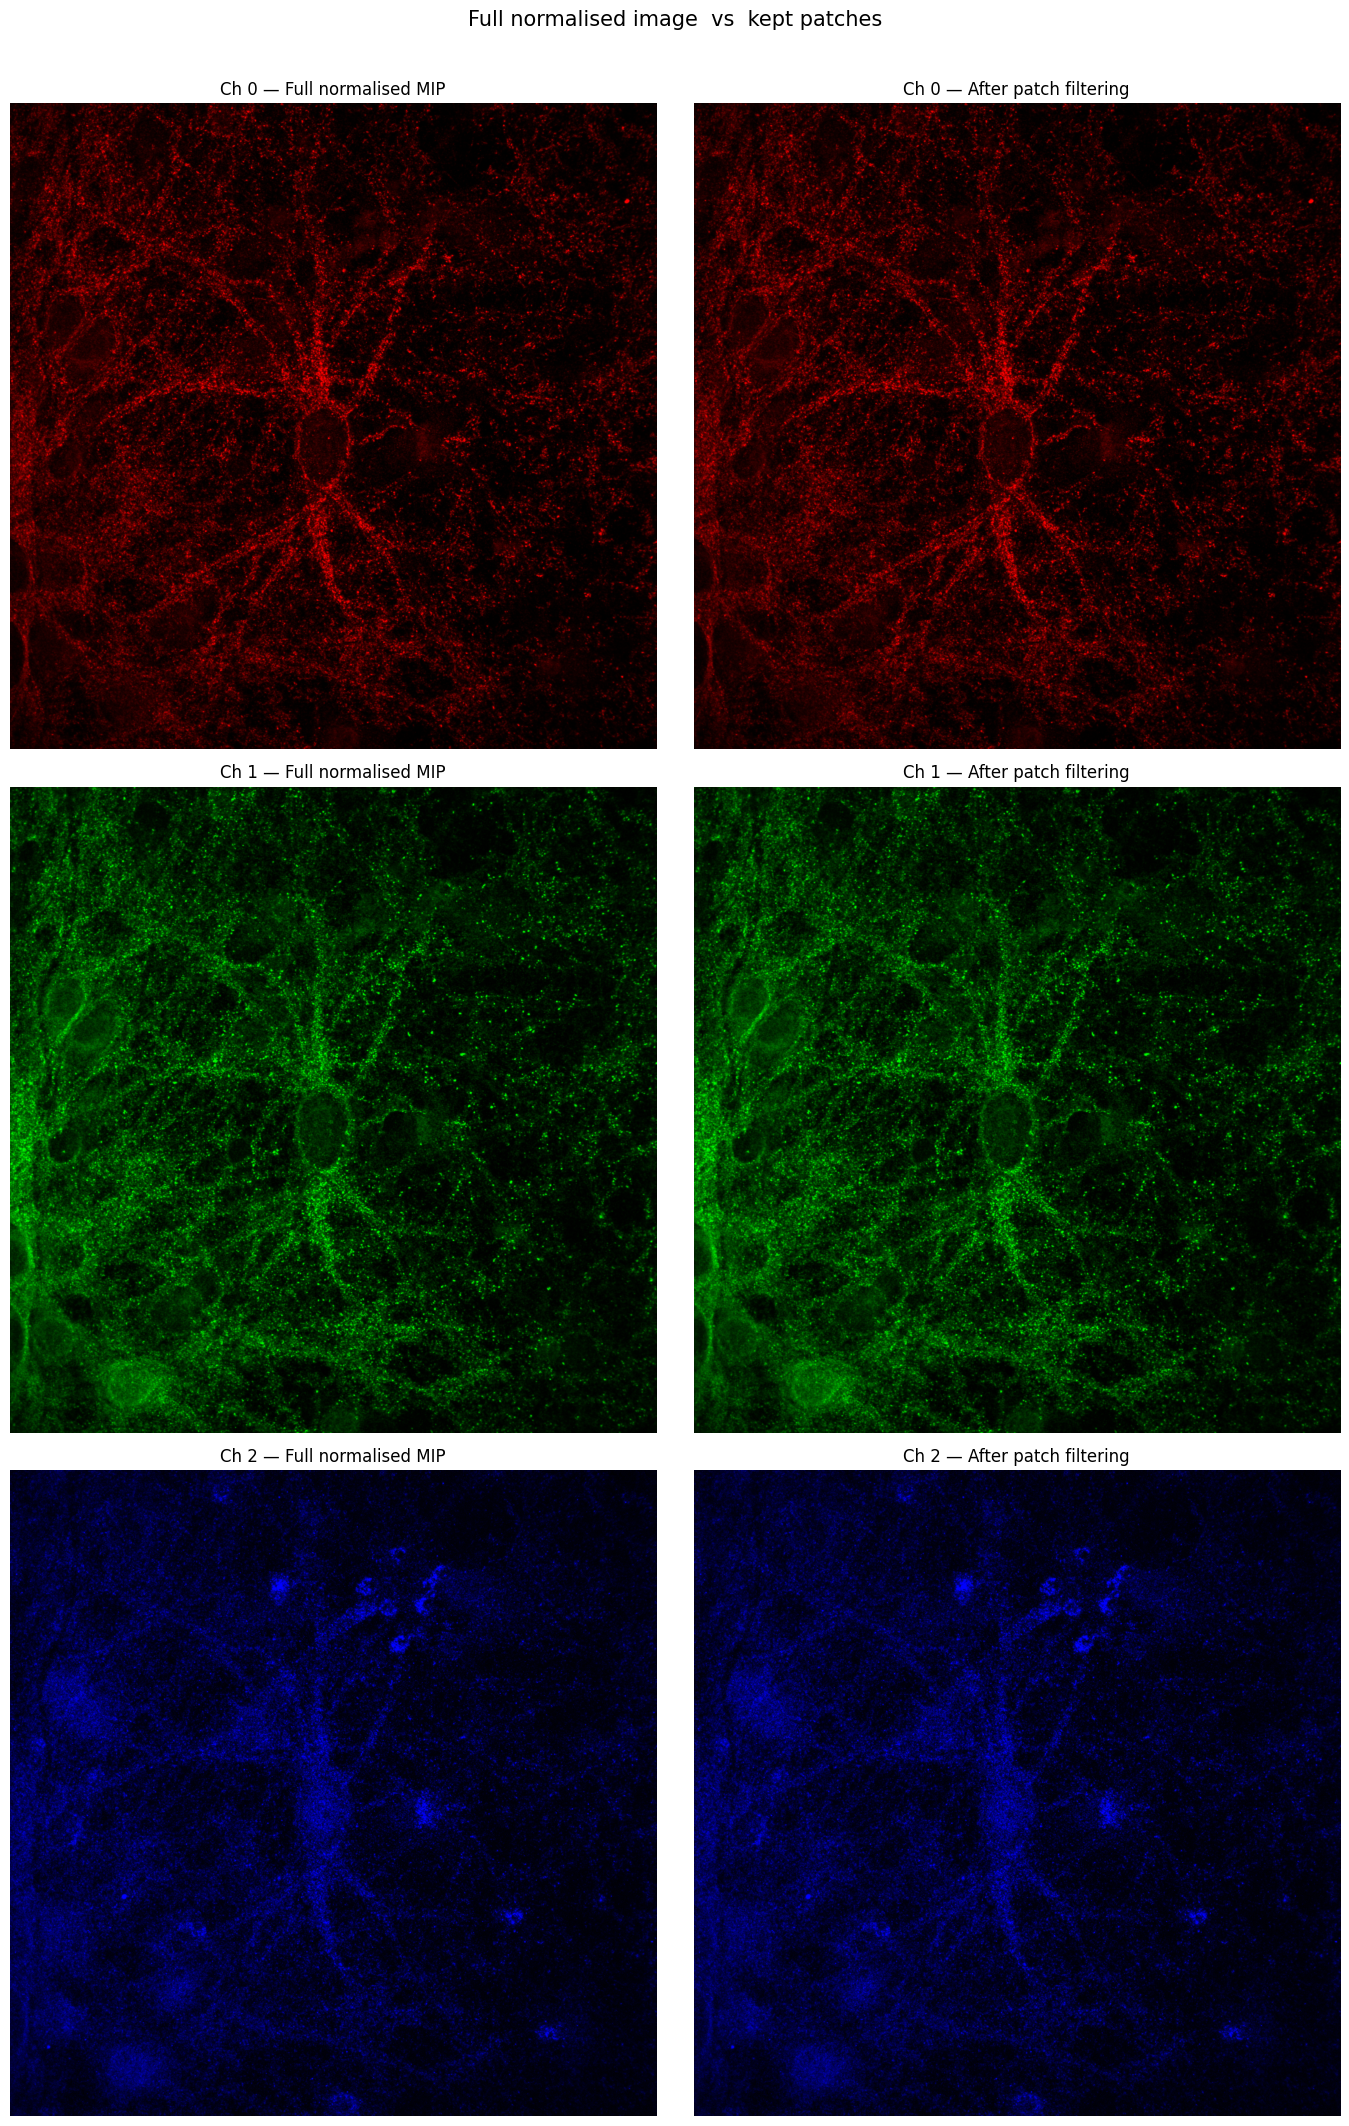

In [69]:
fig, axes = plt.subplots(C_img, 2, figsize=(14, 7 * C_img))
if C_img == 1:
    axes = axes.reshape(1, 2)

for c in range(C_img):
    cmap = CHANNEL_CMAPS[c % len(CHANNEL_CMAPS)]

    # Full normalised image
    axes[c, 0].imshow(mip_norm[c], cmap=cmap, vmin=0, vmax=1)
    axes[c, 0].set_title(f'Ch {c} — Full normalised MIP')
    axes[c, 0].axis('off')

    # Reassembled kept patches
    grid = reassemble_grid(patches, fg_mask, n_rows, n_cols, PATCH_SIZE, channel=c)
    cmap_copy = cmap.copy()
    cmap_copy.set_bad(color='white')
    axes[c, 1].imshow(grid, cmap=cmap_copy, vmin=0, vmax=1)
    axes[c, 1].set_title(f'Ch {c} — After patch filtering')
    axes[c, 1].axis('off')

fig.suptitle('Full normalised image  vs  kept patches', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()
plt.close(fig)